
Árbol de Decisión (Sin Poda):
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.60      0.75      0.67         4

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10

Matriz de Confusión (Sin Poda):
 [[4 2]
 [1 3]]


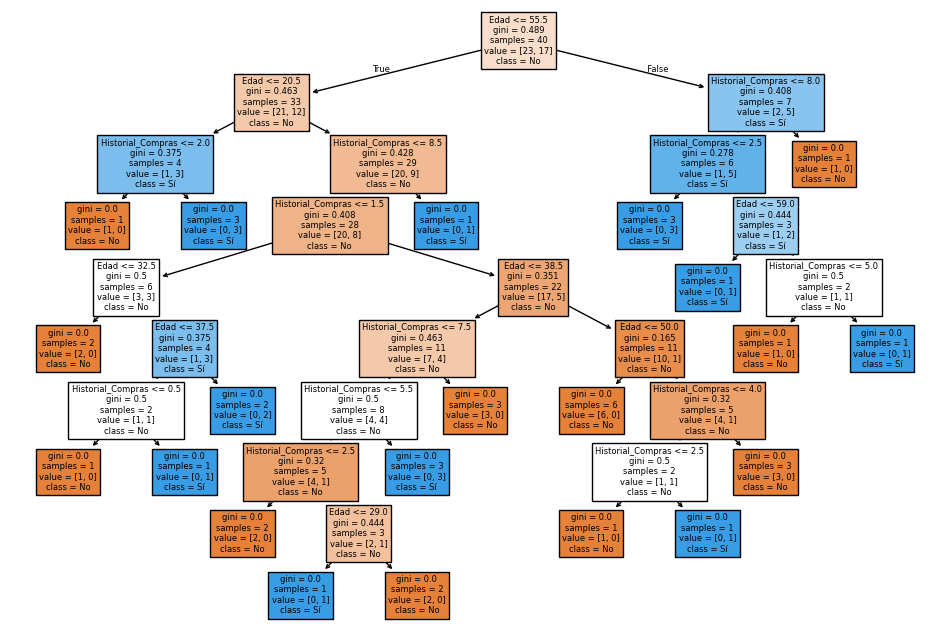


Árbol de Decisión (Poda Previa):
              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.00      0.00      0.00         4

    accuracy                           0.50        10
   macro avg       0.28      0.42      0.33        10
weighted avg       0.33      0.50      0.40        10

Matriz de Confusión (Poda Previa):
 [[5 1]
 [4 0]]


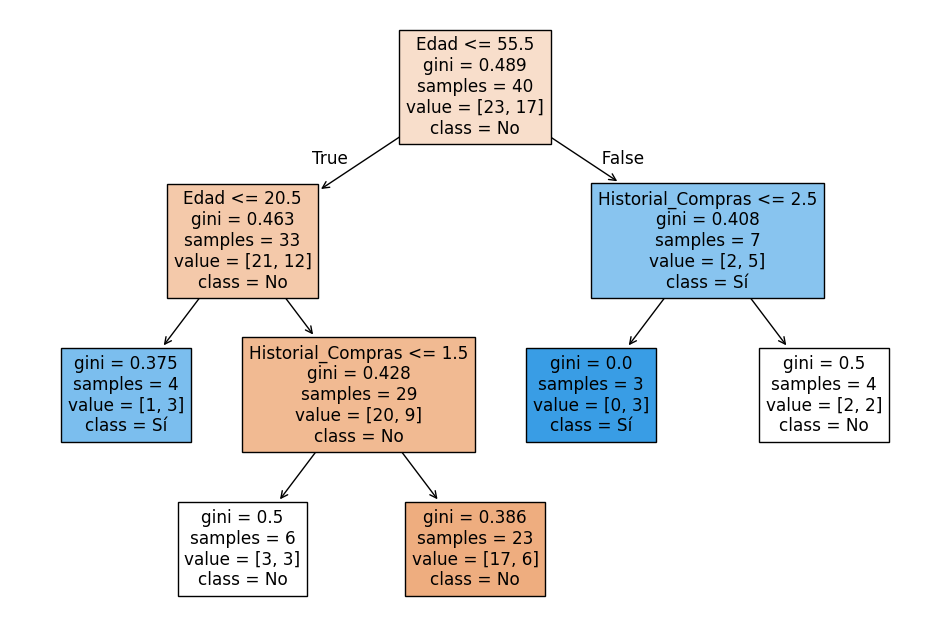


Regresión Logística:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         6
           1       0.00      0.00      0.00         4

    accuracy                           0.60        10
   macro avg       0.30      0.50      0.38        10
weighted avg       0.36      0.60      0.45        10

Matriz de Confusión (Regresión Logística):
 [[6 0]
 [4 0]]

Bosque Aleatorio:
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.50      0.75      0.60         4

    accuracy                           0.60        10
   macro avg       0.62      0.62      0.60        10
weighted avg       0.65      0.60      0.60        10

Matriz de Confusión (Bosque Aleatorio):
 [[3 3]
 [1 3]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Generación de datos simulados con dos variables cuantitativas
np.random.seed(100)
n_samples = 50
data = {
    'Edad': np.random.randint(18, 65, n_samples),
    'Historial_Compras': np.random.randint(0, 10, n_samples),
    'Respuesta_Campaña': np.random.choice([0, 1], n_samples, p=[0.5, 0.5])  # 0: No responde, 1: Responde
}
df = pd.DataFrame(data)

# 2. División de datos (sin preprocesamiento adicional)
X = df[['Edad', 'Historial_Compras']]  # Seleccionamos las dos variables cuantitativas
y = df['Respuesta_Campaña']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modelos de árbol de decisión

# a) Sin poda
tree_model_no_pruned = DecisionTreeClassifier(random_state=42)
tree_model_no_pruned.fit(X_train, y_train)
tree_predictions_no_pruned = tree_model_no_pruned.predict(X_test)

# b) Poda previa (pre-pruning)
tree_model_pre_pruned = DecisionTreeClassifier(
    max_depth=3,  # Profundidad máxima
    min_samples_split=5,  # Mínimo de muestras para dividir
    min_samples_leaf=2,  # Mínimo de muestras en una hoja
    random_state=42
)
tree_model_pre_pruned.fit(X_train, y_train)
tree_predictions_pre_pruned = tree_model_pre_pruned.predict(X_test)



# 4. Otros modelos

# a) Regresión Logística
logreg_model = LogisticRegression(random_state=100)
logreg_model.fit(X_train, y_train)
logreg_predictions = logreg_model.predict(X_test)

# b) Bosque Aleatorio
forest_model = RandomForestClassifier(random_state=100)
forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

# 5. Evaluación y comparación de todos los modelos

# Árbol sin podar
print("\nÁrbol de Decisión (Sin Poda):")
print(classification_report(y_test, tree_predictions_no_pruned))
cm_no_pruned = confusion_matrix(y_test, tree_predictions_no_pruned)
print("Matriz de Confusión (Sin Poda):\n", cm_no_pruned)
plt.figure(figsize=(12, 8))
tree.plot_tree(tree_model_no_pruned, feature_names=X.columns, class_names=['No', 'Sí'], filled=True)
plt.show()

# Árbol con poda previa
print("\nÁrbol de Decisión (Poda Previa):")
print(classification_report(y_test, tree_predictions_pre_pruned))
cm_pre_pruned = confusion_matrix(y_test, tree_predictions_pre_pruned)
print("Matriz de Confusión (Poda Previa):\n", cm_pre_pruned)
plt.figure(figsize=(12, 8))
tree.plot_tree(tree_model_pre_pruned, feature_names=X.columns, class_names=['No', 'Sí'], filled=True)
plt.show()



# Regresión Logística
print("\nRegresión Logística:")
print(classification_report(y_test, logreg_predictions))
cm_logreg = confusion_matrix(y_test, logreg_predictions)
print("Matriz de Confusión (Regresión Logística):\n", cm_logreg)

# Bosque Aleatorio
print("\nBosque Aleatorio:")
print(classification_report(y_test, forest_predictions))
cm_forest = confusion_matrix(y_test, forest_predictions)
print("Matriz de Confusión (Bosque Aleatorio):\n", cm_forest)
